# (16) drifting grating analysis w/ best fit: (16, 20.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from utils.animation import show_movie


device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Drifting grating feeder

In [3]:
n_frames_for_full_cycle = 500
n_cycles_per_image = 4

feeder_kws = dict(
    npix=16,
    #
    theta=0.0,
    s_freq=n_cycles_per_image,
    t_freq=1 / n_frames_for_full_cycle,
    contrast=np.linspace(0.4, 1.0, 64),
    normalize_coords=True,
    #
    device=device,
    flatten=False,
)
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

In [4]:
frames = [feeder[t] for t in range(n_frames_for_full_cycle + 1)]
frames = torch.cat(frames, dim=1)
frames.shape

torch.Size([64, 501, 16, 16])

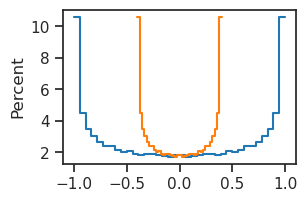

In [5]:
histplot(frames[-1].ravel(), stat='percent')
histplot(frames[0].ravel(), stat='percent');

In [6]:
show_movie(tonp(frames[-1].squeeze()), vmin=-1.0, vmax=1.0)

In [7]:
show_movie(tonp(frames[0].squeeze()), vmin=-1.0, vmax=1.0)

## Load trainer

In [8]:
model_name = 'vH16_t-16_z-[512]_<grad|lin>'
fit_name = 'b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_15,09:26)'

tr, meta = load_model(f"{model_name}/{fit_name}", device)

In [9]:
feeder_kws['flatten'] = True
feeder = FEEDER_CLASSES['drifting-grating'](**feeder_kws)

In [10]:
%%time

output = tr.model.xtract_ftr(
    feeder=feeder,
    seq=range(10000),
    return_extras=True,
).stack()

CPU times: user 22.9 s, sys: 450 ms, total: 23.3 s
Wall time: 19.3 s


In [11]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1))

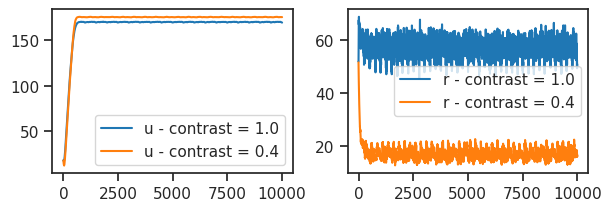

In [12]:
fig, axes = create_figure(1, 2)
axes[0].plot(u_norm[-1], ls='-', label='u - contrast = 1.0')
axes[0].plot(u_norm[0], label='u - contrast = 0.4')
axes[1].plot(r_norm[-1], ls='-', label='r - contrast = 1.0')
axes[1].plot(r_norm[0], label='r - contrast = 0.4')

add_legend(axes)
plt.show()

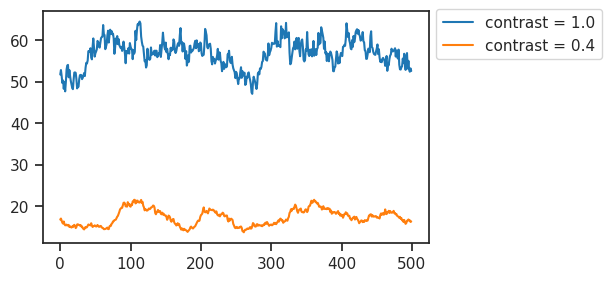

In [13]:
fig, ax = create_figure(1, 1, (6, 2.7))

intvl = range(1000, 1500)
ax.plot(r_norm[-1][intvl], ls='-', label='contrast = 1.0')
ax.plot(r_norm[0][intvl], label='contrast = 0.4')

add_legend(ax)
move_legend(ax, bbox=(1, 1.04))

plt.show()

### Most responsive neurons

In [32]:
firing_rates = torch.exp(output['u'])
r_norms_time = torch.linalg.norm(firing_rates, dim=1)

firing_rates.shape, r_norms_time.shape

(torch.Size([64, 10000, 512]), torch.Size([64, 512]))

In [33]:
contrast_i = -1

most_active_neurons = np.argsort(tonp(
    r_norms_time[contrast_i]
))[::-1]

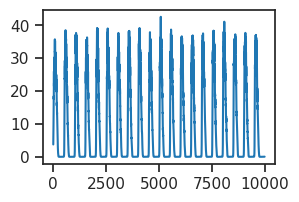

In [34]:
neuron_i = most_active_neurons[0]
plot(firing_rates[-1, :, neuron_i])

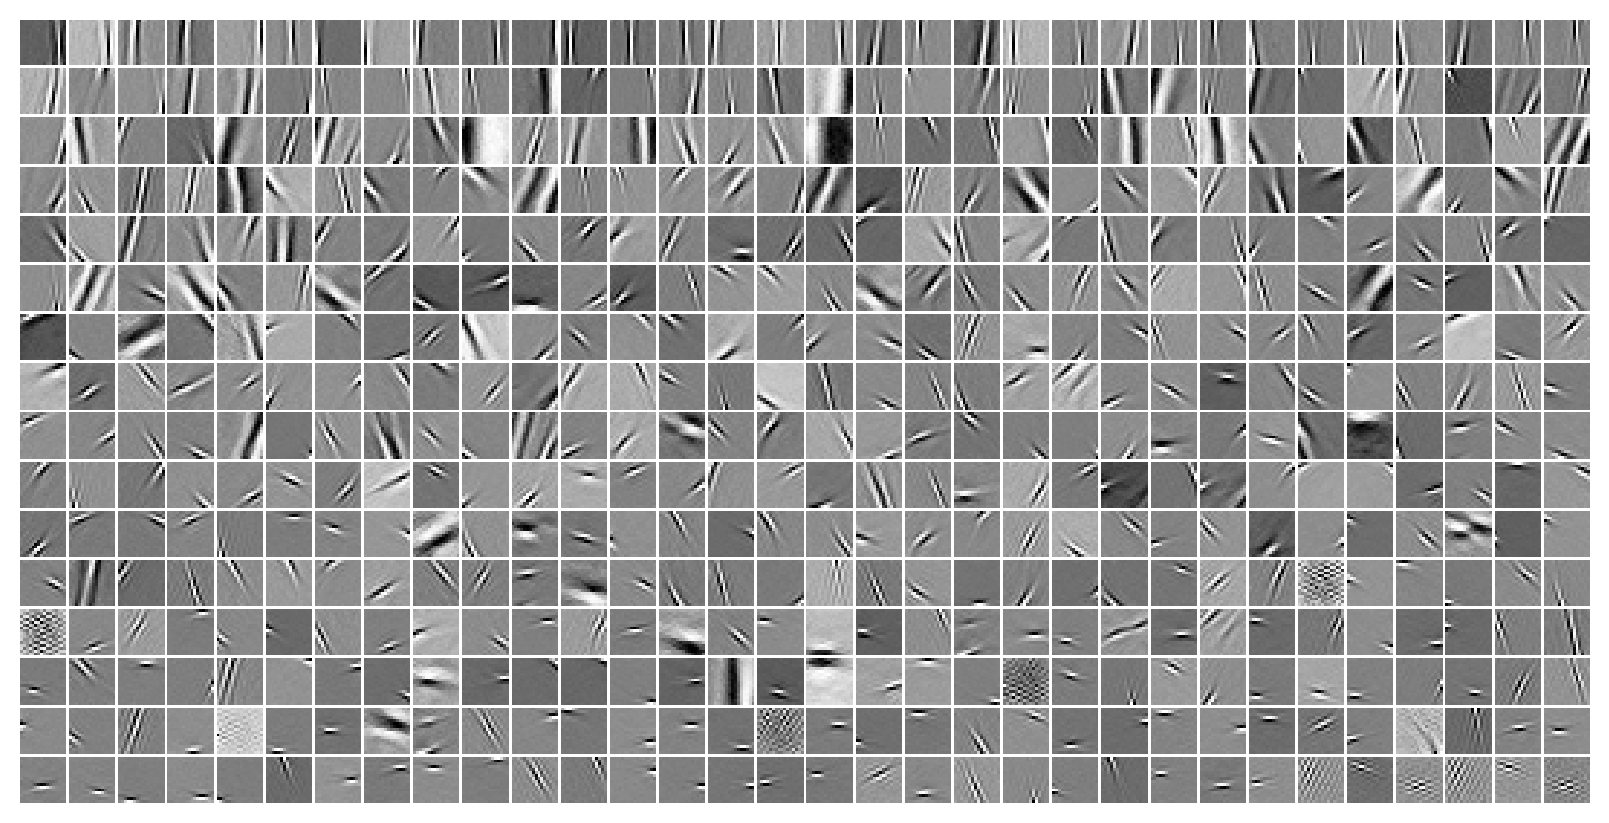

In [35]:
tr.model.show(order=most_active_neurons);

In [46]:
spks_high_contrast = tonp(output['samples'][-1, :, most_active_neurons[0]])
spks_low_contrast = tonp(output['samples'][0, :, most_active_neurons[0]])

spks_low_contrast.shape, spks_high_contrast.shape

((10000,), (10000,))

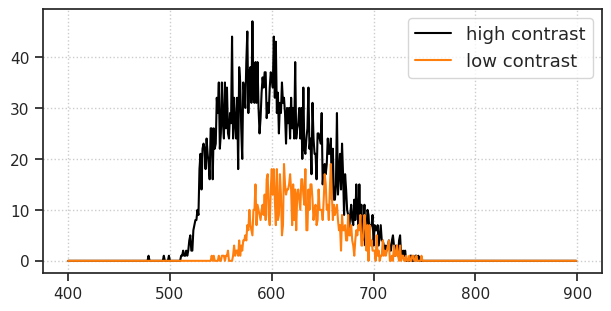

In [59]:
intvl = range(400, 900)

fig, ax = create_figure(1, 1, (6, 3))
ax.plot(intvl, spks_high_contrast[intvl], color='k', label='high contrast')
ax.plot(intvl, spks_low_contrast[intvl], color='C1', label='low contrast')
# ax.axvline(500, color='dimgrey', ls='--', label='stimulus onset')

ax.legend(fontsize=13)
ax.grid()

plt.show()

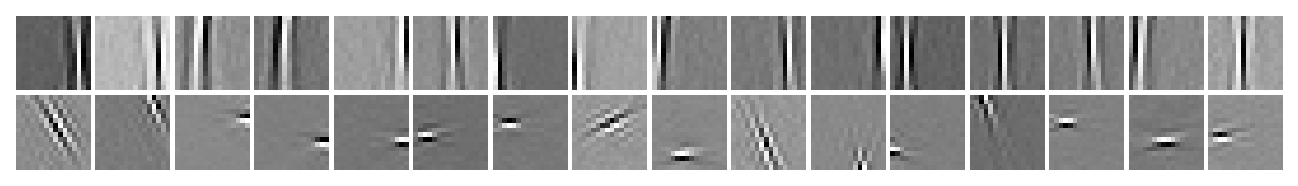

In [69]:
w = tonp(tr.model.layer.get_weight())
w = w.T.reshape(-1, 16, 16)

num = 16
num_skip = 6

x2p = np.concatenate([
    w[most_active_neurons[:num]],
    w[most_active_neurons[-num-num_skip:-num_skip]],
], axis=0)

plot_weights(x2p, nrows=2)
plt.show()

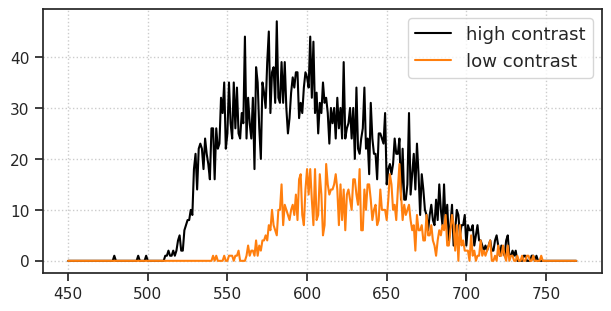

In [71]:
intvl = range(450, 770)

fig, ax = create_figure(1, 1, (6, 3))
ax.plot(intvl, spks_high_contrast[intvl], color='k', label='high contrast')
ax.plot(intvl, spks_low_contrast[intvl], color='C1', label='low contrast')
# ax.axvline(500, color='dimgrey', ls='--', label='stimulus onset')

ax.legend(fontsize=13)
ax.grid()

plt.show()

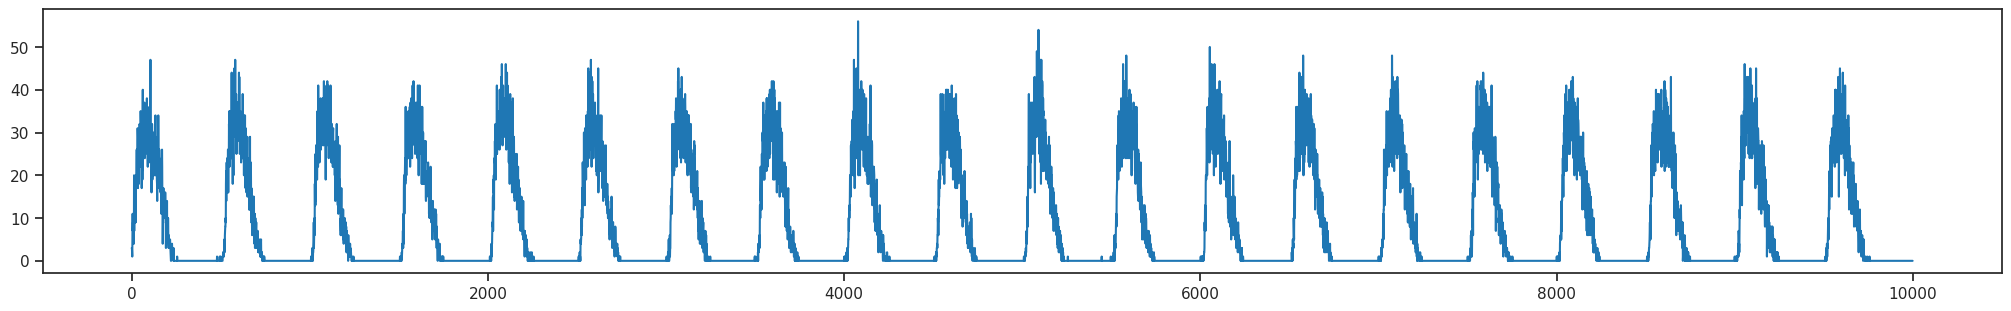

In [75]:
fig, ax = create_figure(1, 1, (20, 3))
plt.plot(spks_high_contrast)

## Evaluate to make sure

In [4]:
print(tr.model.layer.n_exp)

tensor([23, 31, 43, 57, 70, 79, 84, 87, 88, 88, 89, 89, 89, 89, 88, 89],
       device='cuda:0', dtype=torch.int32)

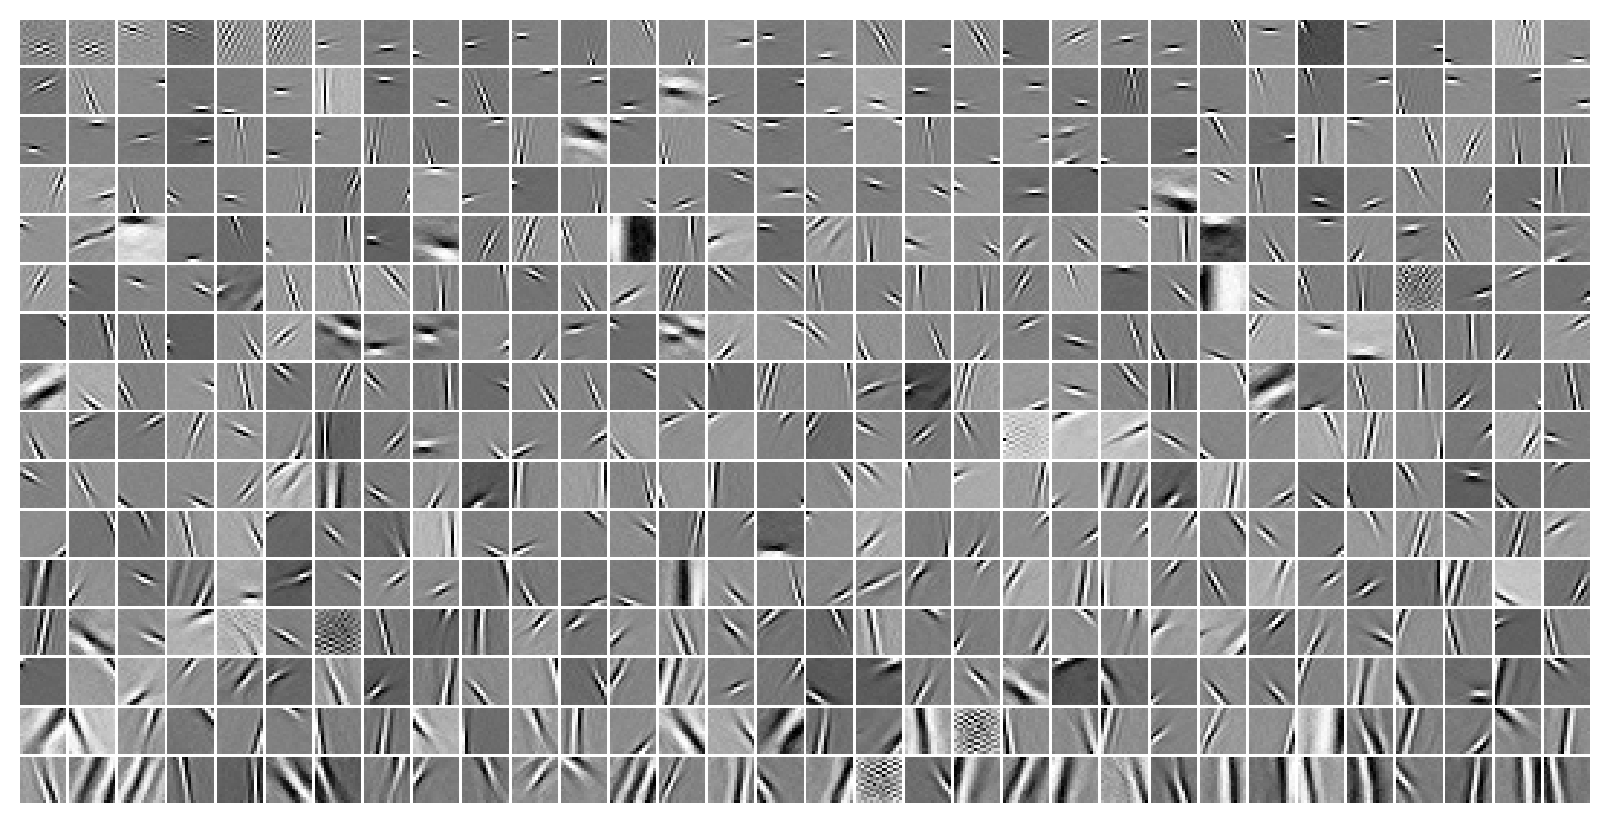

In [5]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

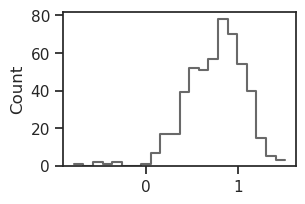

In [6]:
histplot(u0, color='dimgrey');

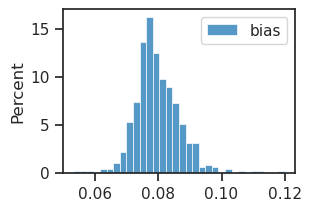

In [7]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.58s/it]


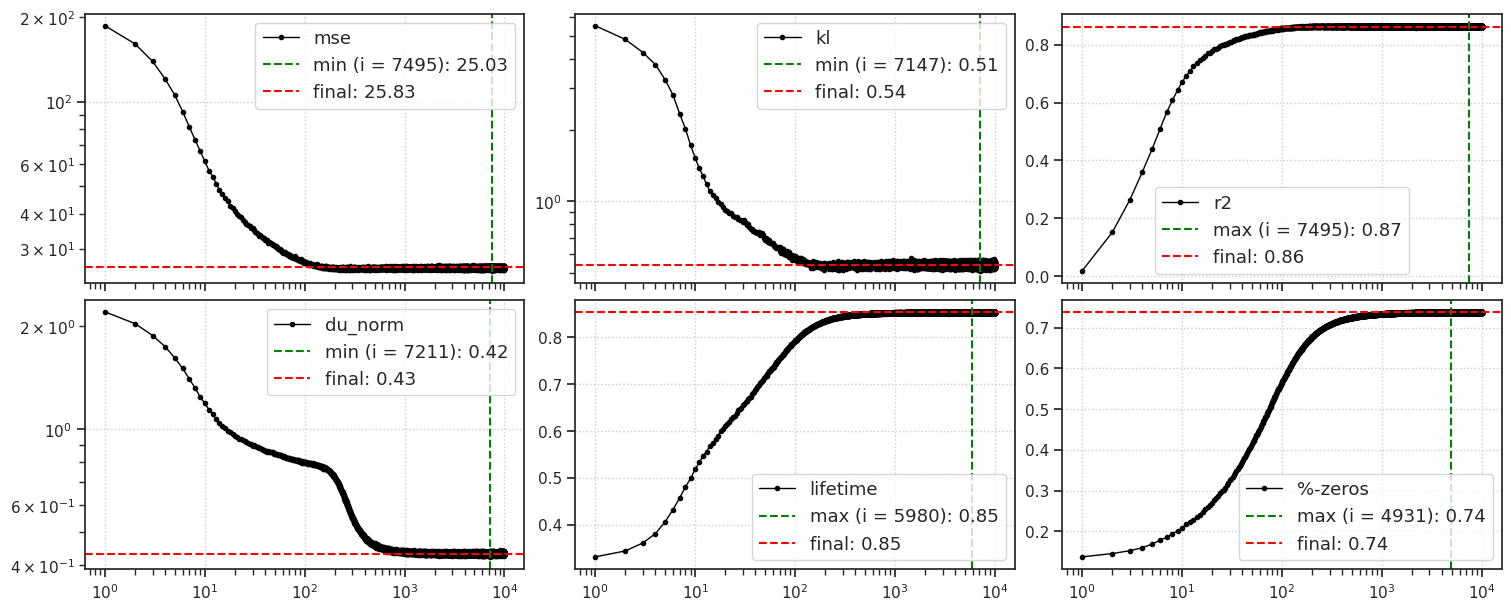

CPU times: user 49.4 s, sys: 2.76 s, total: 52.1 s
Wall time: 52.2 s


In [8]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [9]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

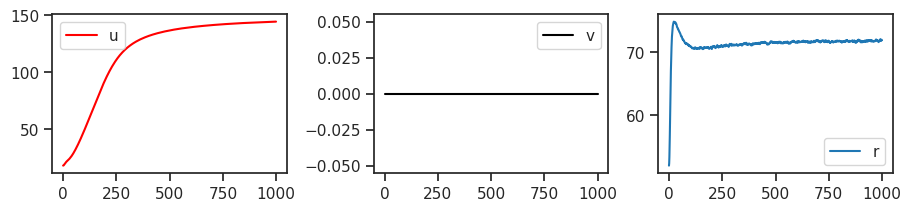

In [10]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()